<a href="https://colab.research.google.com/github/seungah-lab/Intelligence-powered-epidemiology/blob/main/Weel_4_metplotlib_ex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 선형회귀 기계학습에서 경사하강법 적용해 보기

##### 데이터셋: https://hastie.su.domains/ElemStatLearn/ (통계로 배우는 머신러닝)
##### 코드: https://github.com/taehojo/deeplearning_4th/tree/master?tab=readme-ov-file (조태호(2025). 모두의 딥러닝. 개정판 4판)

### 1.환경 준비

In [3]:
import numpy as np
import matplotlib.pyplot as plt

### 2. 데이터 준비

In [19]:
# prostate.data의 상위 10개 행 데이터 입력
# x: 연령 (age), y: 로그변환한 전립선 특이 항원 PSA 수치 (lpsa)

x = np.array([50, 58, 74, 58, 62, 50, 64, 58, 47, 63])
y = np.array([-0.4307829, -0.1625189, 0.5625189, -0.1625189, 0.3715636,
              0.3654678, 0.7654678, 0.8544153, 0.0473190, 1.0473190])

# 데이터 확인 출력
print("독립변수 (Age):", x)
print("종속변수 (lpsa):", y)

# 기초 통계량 확인 (예시)
print(f"평균 연령: {np.mean(x):.2f}")
print(f"평균 lpsa: {np.mean(y):.4f}")


독립변수 (Age): [50 58 74 58 62 50 64 58 47 63]
종속변수 (lpsa): [-0.4307829 -0.1625189  0.5625189 -0.1625189  0.3715636  0.3654678
  0.7654678  0.8544153  0.047319   1.047319 ]
평균 연령: 58.40
평균 lpsa: 0.3258


### 3. 데이터 분포 확인

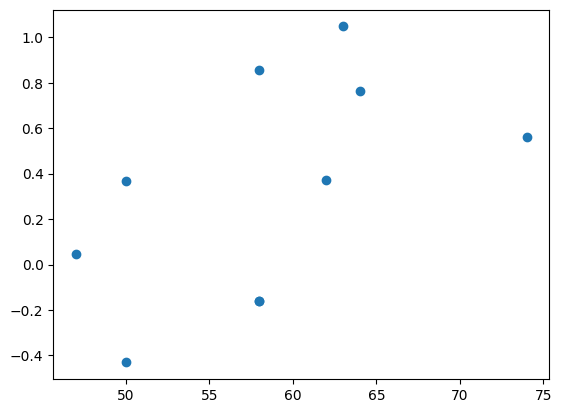

In [23]:
# 데이터의 분포를 그래프로 나타냅니다.
plt.scatter(x, y)
plt.show()


# 데이터 정규화(Feature Scaling)
# x의 범위를 줄여 경사 발산을 막습니다.
x_scaled = (x - np.mean(x)) / np.std(x)

### 4. 실행을 위한 변수 설정

In [24]:
# 기울기 a와 절편 b의 값을 초기화합니다.
a = 0
b = 0

# 학습률을 정합니다.
lr = 0.01

# 몇 번 반복될지 설정합니다.
epochs = 2001

### 5. 경사 하강법

In [25]:
# x 값이 총 몇 개인지 셉니다.
n=len(x)

# 경사 하강법을 시작합니다.
for i in range(epochs):                  # 에포크 수 만큼 반복

    y_pred = a * x_scaled + b                   # 예측 값을 구하는 식입니다.
    error = y - y_pred                   # 실제 값과 비교한 오차를 error로 놓습니다.

    a_diff = (2/n) * sum(-x_scaled * (error))   # 오차 함수를 a로 편미분한 값입니다.
    b_diff = (2/n) * sum(-(error))       # 오차 함수를 b로 편미분한 값입니다.

    a = a - lr * a_diff     # 학습률을 곱해 기존의 a 값을 업데이트합니다.
    b = b - lr * b_diff     # 학습률을 곱해 기존의 b 값을 업데이트합니다.

    if i % 100 == 0:        # 100번 반복될 때마다 현재의 a 값, b 값을 출력합니다.
        print("epoch=%.f, 기울기=%.04f, 절편=%.04f" % (i, a, b))

epoch=0, 기울기=0.0050, 절편=0.0065
epoch=100, 기울기=0.2172, 절편=0.2835
epoch=200, 기울기=0.2453, 절편=0.3202
epoch=300, 기울기=0.2490, 절편=0.3251
epoch=400, 기울기=0.2495, 절편=0.3257
epoch=500, 기울기=0.2496, 절편=0.3258
epoch=600, 기울기=0.2496, 절편=0.3258
epoch=700, 기울기=0.2496, 절편=0.3258
epoch=800, 기울기=0.2496, 절편=0.3258
epoch=900, 기울기=0.2496, 절편=0.3258
epoch=1000, 기울기=0.2496, 절편=0.3258
epoch=1100, 기울기=0.2496, 절편=0.3258
epoch=1200, 기울기=0.2496, 절편=0.3258
epoch=1300, 기울기=0.2496, 절편=0.3258
epoch=1400, 기울기=0.2496, 절편=0.3258
epoch=1500, 기울기=0.2496, 절편=0.3258
epoch=1600, 기울기=0.2496, 절편=0.3258
epoch=1700, 기울기=0.2496, 절편=0.3258
epoch=1800, 기울기=0.2496, 절편=0.3258
epoch=1900, 기울기=0.2496, 절편=0.3258
epoch=2000, 기울기=0.2496, 절편=0.3258


### 6. 그래프 확인

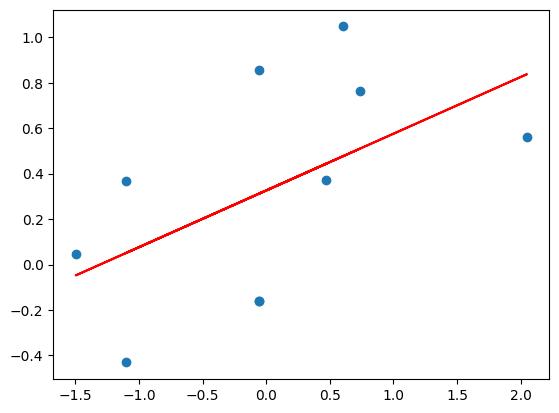

In [26]:
# 앞서 구한 최종 a 값을 기울기, b 값을 y 절편에 대입하여 그래프를 그립니다.
y_pred = a * x_scaled + b

# 그래프 출력
plt.scatter(x_scaled, y)
plt.plot(x_scaled, y_pred,'r')
plt.show()

## 4. 파이썬 코딩으로 확인하는 다중 선형 회귀

### 1.환경 준비

In [28]:
import numpy as np
import matplotlib.pyplot as plt

### 2. 데이터 준비

In [29]:
# prostate.data의 상위 10개 행 데이터 입력
# x1: lweight (전립선 무게의 로그값)
# x2: gleason (글리슨 점수 - 암의 악성도 지표)
# y : lpsa (전립선 특이 항원 수치의 로그값)

x1 = np.array([2.769459, 3.319626, 2.691243, 3.282789, 3.432373,
               3.228826, 3.473518, 3.539509, 3.539509, 3.244544])

x2 = np.array([6, 6, 7, 6, 6, 6, 6, 6, 6, 6])

y = np.array([-0.4307829, -0.1625189, -0.1625189, -0.1625189, 0.3715636,
              0.7654678, 0.7654678, 0.8544153, 1.0473190, 1.0473190])

# 행렬 연산을 위해 x1과 x2를 하나의 행렬 X로 합치는 방법 (선택 사항)
# X는 (10, 2) 형태의 행렬이 되며, 이는 X ∈ R^2 공간의 데이터 10개를 의미합니다.
X = np.column_stack((x1, x2))

print("독립변수 x1 (lweight):", x1)
print("독립변수 x2 (gleason):", x2)
print("종속변수 y (lpsa):", y)
print("\n결합된 입력 행렬 X (첫 5행):\n", X[:5])

독립변수 x1 (lweight): [2.769459 3.319626 2.691243 3.282789 3.432373 3.228826 3.473518 3.539509
 3.539509 3.244544]
독립변수 x2 (gleason): [6 6 7 6 6 6 6 6 6 6]
종속변수 y (lpsa): [-0.4307829 -0.1625189 -0.1625189 -0.1625189  0.3715636  0.7654678
  0.7654678  0.8544153  1.047319   1.047319 ]

결합된 입력 행렬 X (첫 5행):
 [[2.769459 6.      ]
 [3.319626 6.      ]
 [2.691243 7.      ]
 [3.282789 6.      ]
 [3.432373 6.      ]]


### 3. 데이터 분포 확인

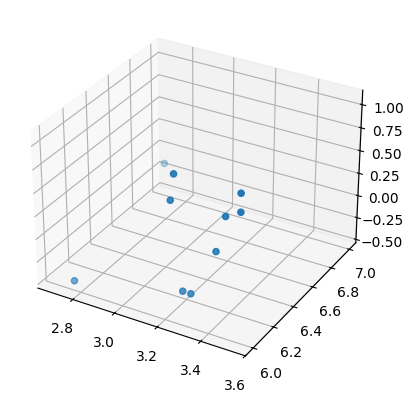

In [30]:
# 데이터의 분포를 그래프로 나타냅니다.
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter3D(x1, x2, y)
plt.show()

### 4. 실행을 위한 변수 설정

In [31]:
# 기울기 a와 절편 b의 값을 초기화합니다.
a1 = 0
a2 = 0
b = 0

# 학습률을 정합니다.
lr = 0.01

# 몇 번 반복될지 설정합니다.
epochs = 2001

### 5. 경사 하강법

In [32]:
# x 값이 총 몇 개인지 셉니다. x1과 x2의 수가 같으므로 x1만 세겠습니다.
n=len(x1)

# 경사 하강법을 시작합니다.
for i in range(epochs):                  # 에포크 수 만큼 반복

    y_pred = a1 * x1 + a2 * x2 + b       # 예측 값을 구하는 식을 세웁니다
    error = y - y_pred                   # 실제 값과 비교한 오차를 error로 놓습니다.

    a1_diff = (2/n) * sum(-x1 * (error)) # 오차 함수를 a1로 편미분한 값입니다.
    a2_diff = (2/n) * sum(-x2 * (error)) # 오차 함수를 a2로 편미분한 값입니다.
    b_diff = (2/n) * sum(-(error))       # 오차 함수를 b로 편미분한 값입니다.

    a1 = a1 - lr * a1_diff  # 학습률을 곱해 기존의 a1 값을 업데이트합니다.
    a2 = a2 - lr * a2_diff  # 학습률을 곱해 기존의 a2 값을 업데이트합니다.
    b = b - lr * b_diff     # 학습률을 곱해 기존의 b 값을 업데이트합니다.

    if i % 100 == 0:        # 100번 반복될 때마다 현재의 a1, a2, b 값을 출력합니다.
        print("epoch=%.f, 기울기1=%.04f, 기울기2=%.04f, 절편=%.04f" % (i, a1, a2, b))

epoch=0, 기울기1=0.0277, 기울기2=0.0469, 절편=0.0079
epoch=100, 기울기1=0.2147, 기울기2=-0.0511, 절편=0.0076
epoch=200, 기울기1=0.3589, 기울기2=-0.1275, 절편=0.0054
epoch=300, 기울기1=0.4704, 기울기2=-0.1862, 절편=0.0016
epoch=400, 기울기1=0.5568, 기울기2=-0.2314, 절편=-0.0032
epoch=500, 기울기1=0.6237, 기울기2=-0.2661, 절편=-0.0089
epoch=600, 기울기1=0.6756, 기울기2=-0.2927, 절편=-0.0153
epoch=700, 기울기1=0.7159, 기울기2=-0.3130, 절편=-0.0221
epoch=800, 기울기1=0.7472, 기울기2=-0.3284, 절편=-0.0294
epoch=900, 기울기1=0.7716, 기울기2=-0.3402, 절편=-0.0369
epoch=1000, 기울기1=0.7906, 기울기2=-0.3490, 절편=-0.0447
epoch=1100, 기울기1=0.8055, 기울기2=-0.3557, 절편=-0.0526
epoch=1200, 기울기1=0.8172, 기울기2=-0.3606, 절편=-0.0607
epoch=1300, 기울기1=0.8264, 기울기2=-0.3642, 절편=-0.0689
epoch=1400, 기울기1=0.8338, 기울기2=-0.3667, 절편=-0.0771
epoch=1500, 기울기1=0.8396, 기울기2=-0.3685, 절편=-0.0854
epoch=1600, 기울기1=0.8444, 기울기2=-0.3696, 절편=-0.0938
epoch=1700, 기울기1=0.8482, 기울기2=-0.3703, 절편=-0.1021
epoch=1800, 기울기1=0.8514, 기울기2=-0.3706, 절편=-0.1105
epoch=1900, 기울기1=0.8541, 기울기2=-0.3707, 절편=-0.1189
epoch=2000, 기울기1=

In [34]:
# 실제 점수와 예측된 점수를 출력합니다.
print("실제 로그변환된 PSA 수치:", y)
print("예측 수치:", y_pred)

실제 로그변환된 PSA 수치: [-0.4307829 -0.1625189 -0.1625189 -0.1625189  0.3715636  0.7654678
  0.7654678  0.8544153  1.047319   1.047319 ]
예측 수치: [ 0.02126572  0.49236264 -0.41619696  0.46081986  0.58890563  0.41461243
  0.62413726  0.68064403  0.68064403  0.42807144]


## 5-1. 텐서플로에서 실행하는 선형 회귀 모델

### 1.환경 준비

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# 텐서플로의 케라스 API에서 필요한 함수들을 불러옵니다.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### 2. 데이터 준비

In [67]:
# 1. 데이터 준비 (prostate.data 상위 10개 행 기반)
# x: 연령의 로그값 (log_age), y: PSA 수치의 로그값 (lpsa)
x_train = np.log(np.array([50, 58, 74, 58, 62, 50, 64, 58, 47, 63]))
y_train = np.array([-0.4307829, -0.1625189, -0.1625189, -0.1625189, 0.3715636,
                    0.7654678, 0.7654678, 0.8544153, 1.0473190, 1.0473190])

### 3. 모델 실행

In [68]:
# 2. 모델 생성 및 컴파일 (input_shape를 명시하는 것이 중요합니다)
model = tf.keras.Sequential([
    # input_shape=(1,)은 모델이 1차원 데이터(변수 1개)를 입력받음을 정의
    tf.keras.layers.Dense(1, input_shape=(1,))
])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss='mse')

# 3. 모델 학습 (예측 전 최소한의 학습이 필요합니다)
model.fit(x_train, y_train, epochs=100, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


그래프로 확인

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


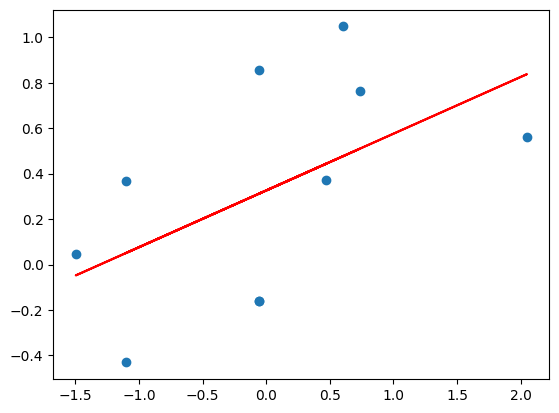

In [56]:
plt.scatter(x, y)
plt.plot(x, model.predict(x),'r')    # 예측 결과를 그래프로 나타냅니다.
plt.show()

### 4. 모델 테스트

In [69]:
import tensorflow as tf

# 4. 문제의 예측 부분 수정
age = 60
log_age = np.log(age)

# [핵심 수정]
# (1) NumPy 배열 사용
# (2) float32 데이터 타입 명시
# (3) [[...]] 2차원 리스트로 배치 차원 확보
input_data = np.array([[log_age]], dtype=np.float32)

# 5. 예측 및 결과 복원
try:
    # verbose=0을 주면 불필요한 로그 출력을 방지합니다.
    predicted_log_psa = model.predict(input_data, verbose=0)[0][0]
    prediction = np.exp(predicted_log_psa)

    print("%d세 남성일 경우의 예상 PSA 수치는 %.02f ng/mL입니다." % (age, prediction))

60세 남성일 경우의 예상 PSA 수치는 1.49 ng/mL입니다.


## 5-2 텐서플로에서 실행하는 다중 선형 회귀 모델

### 1. 데이터 준비

In [73]:
## 바로 앞서 y가 바뀌었으니 다시 정의해 줍시다
# prostate.data의 상위 10개 행 데이터 입력
# x1: lweight (전립선 무게의 로그값)
# x2: gleason (글리슨 점수 - 암의 악성도 지표)
# y : lpsa (전립선 특이 항원 수치의 로그값)

x1 = np.array([2.769459, 3.319626, 2.691243, 3.282789, 3.432373,
               3.228826, 3.473518, 3.539509, 3.539509, 3.244544])

x2 = np.array([6, 6, 7, 6, 6, 6, 6, 6, 6, 6])

y = np.array([-0.4307829, -0.1625189, -0.1625189, -0.1625189, 0.3715636,
              0.7654678, 0.7654678, 0.8544153, 1.0473190, 1.0473190])

### 2. 모델 실행

In [75]:
# [핵심 수정] x1과 x2를 세로로 붙여서 (10, 2) 형체의 행렬로 만듭니다.
# 이렇게 해야 모델이 "아, 입력 변수가 2개구나"라고 정확히 인식합니다.
X = np.column_stack((x1, x2))

# 2. 모델 설정
model = Sequential()

# 입력 변수가 2개이므로 input_dim=2로 설정합니다.
model.add(Dense(1, input_dim=2, activation='linear'))

# 3. 모델 컴파일 및 학습
model.compile(optimizer='sgd', loss='mse')

# 이제 X의 형상이 (10, 2)이므로 에러 없이 실행됩니다.
model.fit(X, y, epochs=500, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 3. 확인을 위한 예측 테스트


In [76]:
# 예: lweight=3.5, gleason=6인 환자의 lpsa 예측
test_data = np.array([[3.5, 6]])
prediction_log = model.predict(test_data, verbose=0)[0][0]
prediction_actual = np.exp(prediction_log)

print("예측된 lpsa(로그값): %.04f" % prediction_log)
print("원래 수치로 복원된 PSA: %.04f" % prediction_actual)

예측된 lpsa(로그값): 0.5917
원래 수치로 복원된 PSA: 1.8070
